# Chapter 52 — Training Loop for the MLP Language Model

## Learning goals

Chapters 50 and 51 built an MLP language model and sampled random context batches.

This chapter combines those pieces into a complete training and evaluation loop.

By the end of this chapter, you should be able to:

- Split an ordered token sequence into training and validation data.
- Run the forward, loss, gradient, and optimizer operations in the correct order.
- Estimate training and validation loss over reproducible sampled batches.
- Explain why evaluation uses `model.eval()` and `torch.no_grad()`.
- Preserve model mode and isolate training randomness during evaluation and generation.
- Generate samples at checkpoints without updating model parameters.
- Plot and interpret training and validation loss.

## The big idea

A training step performs one parameter update:

1. Sample a training batch.
2. Run the model forward.
3. Compute a scalar loss.
4. Clear gradients left by the previous step.
5. Run the backward pass.
6. Ask the optimizer to update the parameters.

At selected checkpoints, evaluation measures loss and generates text without running backward or updating parameters.

## Terms used in this chapter

- A **training set** supplies examples used to update model parameters.
- A **validation set** supplies held-out examples used only to measure performance.
- A **training step** is one optimizer update.
- A **forward pass** computes model outputs from inputs.
- A **backward pass** computes parameter gradients from the loss.
- An **optimizer step** uses gradients to update parameters.
- A **checkpoint** is a chosen training step at which the loop records measurements or samples.
- **Validation loss** is prediction loss measured on validation data without parameter updates.
- `model.train()` selects training mode.
- `model.eval()` selects evaluation mode.
- `torch.no_grad()` disables gradient tracking inside its block.

## Create a toy character corpus

Use a repeated local string so the entire experiment runs quickly on the CPU.

This corpus demonstrates training mechanics but is too small and repetitive to measure general language ability.

In [1]:
device = "cpu"
raw_text = (
    "the cat sat on the mat. "
    "the dog sat on the rug. "
    "the cat ran to the dog. "
    "the dog ran to the cat. "
    "the mat sat by the rug. "
    "the cat and the dog ran. "
) * 30

print("device:", device)
print("number of characters:", len(raw_text))
print("first 160 characters:", repr(raw_text[:160]))

device: cpu
number of characters: 4350
first 160 characters: 'the cat sat on the mat. the dog sat on the rug. the cat ran to the dog. the dog ran to the cat. the mat sat by the rug. the cat and the dog ran. the cat sat on '


The repeated sentence group creates many fixed-length windows while keeping their patterns recognizable.

## Encode and decode characters

Build one deterministic vocabulary and define helpers that make tokenized data readable again.

In [2]:
def encode_text(
    text: str,
    character_to_id: dict[str, int],
) -> list[int]:
    return [character_to_id[character] for character in text]


def decode_token_ids(
    token_ids: list[int],
    id_to_character: dict[int, str],
) -> str:
    return "".join(id_to_character[token_id] for token_id in token_ids)


vocabulary = sorted(set(raw_text))
vocabulary_size = len(vocabulary)
character_to_id = {character: token_id for token_id, character in enumerate(vocabulary)}
id_to_character = {
    token_id: character for character, token_id in character_to_id.items()
}

sample_text = "the cat"
sample_token_ids = encode_text(sample_text, character_to_id)
decoded_sample_text = decode_token_ids(sample_token_ids, id_to_character)

print("vocabulary:", vocabulary)
print("vocabulary size:", vocabulary_size)
print("sample token IDs:", sample_token_ids)
print("decoded sample:", repr(decoded_sample_text))

vocabulary: [' ', '.', 'a', 'b', 'c', 'd', 'e', 'g', 'h', 'm', 'n', 'o', 'r', 's', 't', 'u', 'y']
vocabulary size: 17
sample token IDs: [14, 8, 6, 0, 4, 2, 14]
decoded sample: 'the cat'


The decoded sample matches the original string, which verifies the two mappings before training uses them.

## Split the ordered token sequence

Convert the entire corpus to a one-dimensional integer tensor, then reserve its final 10 percent for validation.

The split preserves character order because shuffling raw characters would destroy next-token relationships.

In [3]:
import torch

all_token_ids = torch.tensor(
    encode_text(raw_text, character_to_id),
    dtype=torch.long,
    device=device,
)
train_fraction = 0.9
split_index = int(train_fraction * all_token_ids.shape[0])
train_token_ids = all_token_ids[:split_index]
validation_token_ids = all_token_ids[split_index:]

print("total tokens:", all_token_ids.shape[0])
print("training tokens:", train_token_ids.shape[0])
print("validation tokens:", validation_token_ids.shape[0])
print(
    "split reconstructs data:",
    torch.equal(
        torch.cat((train_token_ids, validation_token_ids)),
        all_token_ids,
    ),
)

total tokens: 4350
training tokens: 3915
validation tokens: 435
split reconstructs data: True


Concatenating the two slices reconstructs the original tensor exactly.

Because this toy corpus repeats the same sentence group, its validation slice contains patterns also seen in training.

The split is useful for learning the evaluation workflow but is not a strong test of generalization.

## Inspect the split boundary

Decode text on both sides of the boundary to confirm that neither slice was shuffled.

In [4]:
training_boundary_text = decode_token_ids(
    train_token_ids[-80:].tolist(),
    id_to_character,
)
validation_boundary_text = decode_token_ids(
    validation_token_ids[:80].tolist(),
    id_to_character,
)

print("end of training text:", repr(training_boundary_text))
print("start of validation text:", repr(validation_boundary_text))

end of training text: 'e dog. the dog ran to the cat. the mat sat by the rug. the cat and the dog ran. '
start of validation text: 'the cat sat on the mat. the dog sat on the rug. the cat ran to the dog. the dog '


The boundary may cut through a sentence, but every slice retains the sequence order present in the corpus.

## Sample one-target batches

Reuse Chapter 51's one-target-per-context layout with an optional generator for isolated reproducibility.

Each input row contains `context_length` consecutive IDs, and its target is the immediately following ID.

In [5]:
def get_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    if token_ids.ndim != 1:
        raise ValueError("token_ids must be a one-dimensional tensor.")
    if batch_size < 1:
        raise ValueError("batch_size must be at least 1.")
    if context_length < 1:
        raise ValueError("context_length must be at least 1.")

    number_of_valid_start_positions = token_ids.shape[0] - context_length
    if number_of_valid_start_positions < 1:
        raise ValueError("token_ids must contain more tokens than context_length.")

    start_indexes = torch.randint(
        low=0,
        high=number_of_valid_start_positions,
        size=(batch_size,),
        generator=generator,
        device=token_ids.device,
    )
    input_rows: list[torch.Tensor] = []
    target_rows: list[torch.Tensor] = []

    for start_index in start_indexes.tolist():
        stop_index = start_index + context_length
        input_rows.append(token_ids[start_index:stop_index])
        target_rows.append(token_ids[stop_index])

    return torch.stack(input_rows), torch.stack(target_rows)


context_length = 4
batch_size = 4
batch_generator = torch.Generator(device=device).manual_seed(52)
input_batch, target_batch = get_batch(
    token_ids=train_token_ids,
    batch_size=batch_size,
    context_length=context_length,
    generator=batch_generator,
)

print("input shape:", input_batch.shape)
print("target shape:", target_batch.shape)
print("input batch IDs:")
print(input_batch)
print("target batch IDs:")
print(target_batch)

input shape: torch.Size([4, 4])
target shape: torch.Size([4])
input batch IDs:
tensor([[ 0, 14,  8,  6],
        [12, 15,  7,  1],
        [ 8,  6,  0,  4],
        [ 0, 14,  8,  6]])
target batch IDs:
tensor([0, 0, 2, 0])


Decode the sampled tensors to verify alignment before sending them to a model.

In [6]:
print("row | context | target")
print("-" * 24)
for row_index in range(input_batch.shape[0]):
    decoded_input = decode_token_ids(
        input_batch[row_index].tolist(),
        id_to_character,
    )
    target_id = int(target_batch[row_index].item())
    print(f"{row_index:>3} | {decoded_input!r:>9} | {id_to_character[target_id]!r}")

row | context | target
------------------------
  0 |    ' the' | ' '
  1 |    'rug.' | ' '
  2 |    'he c' | 'a'
  3 |    ' the' | ' '


Every decoded target is the next character after its intact four-character context.

## Define the MLP language model

Use the Chapter 50 architecture that embeds each token, flattens the context, and returns one vocabulary logit per row.

Cross-entropy expects these raw logits, so the model does not apply softmax in `forward`.

In [7]:
from typing import cast


class MlpLanguageModel(torch.nn.Module):
    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        hidden_size: int,
    ) -> None:
        super().__init__()

        self.context_length: int = context_length
        self.embedding_dimension: int = embedding_dimension
        self.token_embedding_table: torch.nn.Embedding = torch.nn.Embedding(
            vocabulary_size,
            embedding_dimension,
        )
        self.first_linear_layer: torch.nn.Linear = torch.nn.Linear(
            context_length * embedding_dimension,
            hidden_size,
        )
        self.nonlinearity: torch.nn.Tanh = torch.nn.Tanh()
        self.output_layer: torch.nn.Linear = torch.nn.Linear(
            hidden_size, vocabulary_size
        )

    def forward(self, input_token_ids: torch.Tensor) -> torch.Tensor:
        if input_token_ids.ndim != 2:
            raise ValueError(
                "input_token_ids must have shape [batch size, context length]."
            )
        if input_token_ids.shape[1] != self.context_length:
            raise ValueError(
                f"Expected context length {self.context_length}, "
                f"received {input_token_ids.shape[1]}."
            )

        token_embeddings = self.token_embedding_table(input_token_ids)
        flattened_embeddings = token_embeddings.reshape(
            input_token_ids.shape[0],
            self.context_length * self.embedding_dimension,
        )
        hidden_values = self.first_linear_layer(flattened_embeddings)
        activated_hidden_values = self.nonlinearity(hidden_values)
        return cast(torch.Tensor, self.output_layer(activated_hidden_values))

## Inspect one forward pass and loss

Create a deterministic model, run the sampled batch, and confirm the three shapes used by cross-entropy.

In [8]:
torch.manual_seed(52)
embedding_dimension = 16
hidden_size = 64
model = MlpLanguageModel(
    vocabulary_size=vocabulary_size,
    context_length=context_length,
    embedding_dimension=embedding_dimension,
    hidden_size=hidden_size,
).to(device)
loss_function = torch.nn.CrossEntropyLoss()
next_token_logits = model(input_batch)
loss = loss_function(next_token_logits, target_batch)

print(model)
print("parameter count:", sum(parameter.numel() for parameter in model.parameters()))
print("input shape:", input_batch.shape)
print("logit shape:", next_token_logits.shape)
print("target shape:", target_batch.shape)
print("loss shape:", loss.shape)
print("loss:", loss.item())

MlpLanguageModel(
  (token_embedding_table): Embedding(17, 16)
  (first_linear_layer): Linear(in_features=64, out_features=64, bias=True)
  (nonlinearity): Tanh()
  (output_layer): Linear(in_features=64, out_features=17, bias=True)
)
parameter count: 5537
input shape: torch.Size([4, 4])
logit shape: torch.Size([4, 17])
target shape: torch.Size([4])
loss shape: torch.Size([])
loss: 2.859916925430298


The model produces `[batch_size, vocabulary_size]` logits, and cross-entropy reduces the row losses to one scalar.

## Perform one complete training step

Run gradient clearing, backward, and the optimizer update after computing the forward loss.

The full loop will repeat this exact sequence with fresh batches.

In [9]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.02,
    weight_decay=0.0,
)
parameter_before_step = model.output_layer.weight.detach().clone()

optimizer.zero_grad()
loss.backward()
optimizer.step()

parameter_changed = not torch.equal(
    parameter_before_step,
    model.output_layer.weight.detach(),
)

print("loss used for backward:", loss.item())
print("output-layer weight changed:", parameter_changed)

loss used for backward: 2.859916925430298
output-layer weight changed: True


The changed weight confirms that the optimizer used the gradients produced by `loss.backward()`.

Gradients accumulate by default, so the next step must clear them before its backward pass.

## Estimate loss without gradients

Evaluation samples several batches and averages their losses to reduce the noise of a single random batch.

A fixed evaluation seed selects the same sample of windows at every checkpoint, making changes over time easier to compare.

The helper preserves the model's previous mode instead of assuming every caller wants training mode afterward.

In [10]:
def estimate_loss(
    model: MlpLanguageModel,
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    number_of_batches: int,
    loss_function: torch.nn.Module,
    random_seed: int,
) -> float:
    if number_of_batches < 1:
        raise ValueError("number_of_batches must be at least 1.")

    evaluation_generator = torch.Generator(device=token_ids.device).manual_seed(
        random_seed
    )
    was_training = model.training
    model.eval()
    losses: list[float] = []

    try:
        with torch.no_grad():
            for _ in range(number_of_batches):
                input_batch, target_batch = get_batch(
                    token_ids=token_ids,
                    batch_size=batch_size,
                    context_length=context_length,
                    generator=evaluation_generator,
                )
                next_token_logits = model(input_batch)
                loss = loss_function(next_token_logits, target_batch)
                losses.append(loss.item())
    finally:
        model.train(was_training)

    return sum(losses) / len(losses)

Test the helper on both splits and make gradient tracking visible inside a validation forward pass.

In [11]:
training_loss_estimate = estimate_loss(
    model=model,
    token_ids=train_token_ids,
    batch_size=16,
    context_length=context_length,
    number_of_batches=5,
    loss_function=loss_function,
    random_seed=5201,
)
validation_loss_estimate = estimate_loss(
    model=model,
    token_ids=validation_token_ids,
    batch_size=16,
    context_length=context_length,
    number_of_batches=5,
    loss_function=loss_function,
    random_seed=5202,
)
validation_generator = torch.Generator(device=device).manual_seed(5203)
validation_inputs, _ = get_batch(
    validation_token_ids,
    batch_size=2,
    context_length=context_length,
    generator=validation_generator,
)

with torch.no_grad():
    validation_logits = model(validation_inputs)
    gradient_tracking_enabled = torch.is_grad_enabled()

print("training loss estimate:", training_loss_estimate)
print("validation loss estimate:", validation_loss_estimate)
print("gradient tracking inside no_grad:", gradient_tracking_enabled)
print("validation logits require gradients:", validation_logits.requires_grad)
print("model returned to training mode:", model.training)

training loss estimate: 2.5052864074707033
validation loss estimate: 2.5933361053466797
gradient tracking inside no_grad: False
validation logits require gradients: False
model returned to training mode: True


`torch.no_grad()` prevents construction of the graph needed for backward, which saves evaluation memory and work.

`model.eval()` is separate: it changes the behavior of mode-sensitive layers such as dropout, although this MLP contains none.

Validation performs no `backward()` call and no optimizer step.

## Generate without changing training state

Generation repeatedly samples from the probability distribution for the latest context.

It uses a local random generator and restores the model's prior mode so checkpoint samples cannot change the later training batch sequence.

In [12]:
def generate_text(
    model: MlpLanguageModel,
    starting_text: str,
    character_to_id: dict[str, int],
    id_to_character: dict[int, str],
    number_of_new_characters: int,
    random_seed: int,
) -> str:
    if len(starting_text) < model.context_length:
        raise ValueError(
            f"starting_text must contain at least {model.context_length} characters."
        )
    unknown_characters = [
        character for character in starting_text if character not in character_to_id
    ]
    if unknown_characters:
        raise ValueError(f"Unknown characters: {unknown_characters!r}")
    if number_of_new_characters < 0:
        raise ValueError("number_of_new_characters cannot be negative.")

    model_device = next(model.parameters()).device
    generation_generator = torch.Generator(device=model_device).manual_seed(random_seed)
    was_training = model.training
    model.eval()
    generated_characters = list(starting_text)

    try:
        with torch.no_grad():
            for _ in range(number_of_new_characters):
                context_text = "".join(generated_characters[-model.context_length :])
                context_token_ids = torch.tensor(
                    encode_text(context_text, character_to_id),
                    dtype=torch.long,
                    device=model_device,
                ).reshape(1, model.context_length)
                next_token_logits = model(context_token_ids)
                probabilities = torch.softmax(next_token_logits, dim=1).squeeze(0)
                sampled_token_id = int(
                    torch.multinomial(
                        probabilities,
                        num_samples=1,
                        generator=generation_generator,
                    ).item()
                )
                generated_characters.append(id_to_character[sampled_token_id])
    finally:
        model.train(was_training)

    return "".join(generated_characters)

Generate from the nearly untrained demonstration model to establish a before-training comparison.

In [13]:
sample_before_training = generate_text(
    model=model,
    starting_text="the ",
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    number_of_new_characters=80,
    random_seed=52,
)

print("sample before complete training:")
print(repr(sample_before_training))
print("model remains in training mode:", model.training)

sample before complete training:
'the eaubcdnet.bgdbbb aaadryuaarcaynahro acy rsmsaou asgeot.sbcdbcsot.yrurdh. smsottg'
model remains in training mode: True


The output reflects parameters that received only one update, so recognizable corpus patterns should still be unreliable.

## Run the complete training loop

Recreate the model so the main experiment starts from a known initialization.

The loop evaluates at step zero, performs exactly 800 optimizer updates, and evaluates after every 200 updates.

Evaluation and generation use independent random generators, so changing their frequency does not change which training batches are sampled.

In [14]:
torch.manual_seed(52)
context_length = 4
batch_size = 32
model = MlpLanguageModel(
    vocabulary_size=vocabulary_size,
    context_length=context_length,
    embedding_dimension=16,
    hidden_size=64,
).to(device)
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.02,
    weight_decay=0.0,
)
training_generator = torch.Generator(device=device).manual_seed(5200)
number_of_training_steps = 800
evaluation_interval = 200
number_of_evaluation_batches = 20
training_log: list[dict[str, int | float | str]] = []

for step in range(number_of_training_steps + 1):
    if step % evaluation_interval == 0:
        training_loss = estimate_loss(
            model=model,
            token_ids=train_token_ids,
            batch_size=batch_size,
            context_length=context_length,
            number_of_batches=number_of_evaluation_batches,
            loss_function=loss_function,
            random_seed=5201,
        )
        validation_loss = estimate_loss(
            model=model,
            token_ids=validation_token_ids,
            batch_size=batch_size,
            context_length=context_length,
            number_of_batches=number_of_evaluation_batches,
            loss_function=loss_function,
            random_seed=5202,
        )
        generated_sample = generate_text(
            model=model,
            starting_text="the ",
            character_to_id=character_to_id,
            id_to_character=id_to_character,
            number_of_new_characters=80,
            random_seed=52 + step,
        )
        training_log.append(
            {
                "step": step,
                "training_loss": training_loss,
                "validation_loss": validation_loss,
                "generated_sample": generated_sample,
            }
        )

        print("-" * 72)
        print("step:", step)
        print("training loss:", training_loss)
        print("validation loss:", validation_loss)
        print("sample:", repr(generated_sample))

    if step == number_of_training_steps:
        break

    input_batch, target_batch = get_batch(
        token_ids=train_token_ids,
        batch_size=batch_size,
        context_length=context_length,
        generator=training_generator,
    )
    next_token_logits = model(input_batch)
    loss = loss_function(next_token_logits, target_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

------------------------------------------------------------------------
step: 0
training loss: 2.8492658972740172
validation loss: 2.8528059840202333
sample: 'the egubcdnet.bgdbbb atadryuaarcgyaahro acyrrsmsaou nsgeot.sbcdbcsot.yr rdh.u hsottg'


------------------------------------------------------------------------
step: 200
training loss: 0.2818938348442316
validation loss: 0.3458831276744604
sample: 'the dog ran to the dog sat on the cat sat by the cat. the cat. the dog sat on the ca'


------------------------------------------------------------------------
step: 400
training loss: 0.23761176001280546
validation loss: 0.2522570312023163
sample: 'the cat ran to the dog. the dog ran to the cat ran to the cat. the rug. the cat sat '


------------------------------------------------------------------------
step: 600
training loss: 0.24951995499432086
validation loss: 0.27427687514573335
sample: 'the rug. the cat and the cat and the cat and the cat and the rug. the cat ran. the r'


------------------------------------------------------------------------
step: 800
training loss: 0.3241383545100689
validation loss: 0.28502520769834516
sample: 'the rug. the rug. the dog ran to the dog ran to the rug. the cat and the dog sat by '


Loss is measured before the first update and after update counts 200, 400, 600, and 800.

The individual estimates need not decrease at every checkpoint, but both should show a clear overall decline for this deterministic run.

Generated samples should also contain more corpus-like fragments after training.

## Plot training and validation loss

Plot the checkpoint measurements on the same labeled axes to compare their trends.

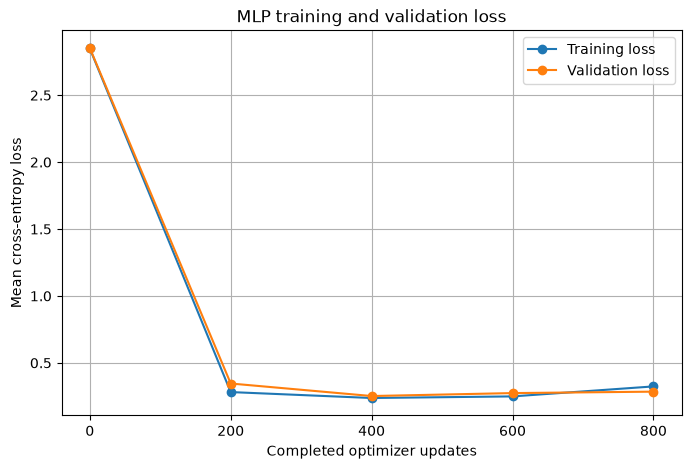

In [15]:
import matplotlib.pyplot as plt

logged_steps = [int(row["step"]) for row in training_log]
logged_training_losses = [float(row["training_loss"]) for row in training_log]
logged_validation_losses = [float(row["validation_loss"]) for row in training_log]

plt.figure(figsize=(8, 5))
plt.plot(logged_steps, logged_training_losses, marker="o", label="Training loss")
plt.plot(
    logged_steps,
    logged_validation_losses,
    marker="o",
    label="Validation loss",
)
plt.xlabel("Completed optimizer updates")
plt.ylabel("Mean cross-entropy loss")
plt.title("MLP training and validation loss")
plt.xticks(logged_steps)
plt.grid(True)
plt.legend()
plt.show()

A falling training curve shows fitting to sampled training windows.

A falling validation curve shows improvement on the held-out slice, but the repeated corpus means this example does not establish broad generalization.

On less repetitive data, rising validation loss alongside falling training loss can indicate overfitting.

## Compare generation before and after training

Generate a longer final sample with a fixed seed and print it beside the earlier baseline.

In [16]:
sample_after_training = generate_text(
    model=model,
    starting_text="the ",
    character_to_id=character_to_id,
    id_to_character=id_to_character,
    number_of_new_characters=160,
    random_seed=52,
)

print("before complete training:")
print(repr(sample_before_training))
print()
print("after complete training:")
print(repr(sample_after_training))

before complete training:
'the eaubcdnet.bgdbbb aaadryuaarcaynahro acy rsmsaou asgeot.sbcdbcsot.yrurdh. smsottg'

after complete training:
'the dog sat by the rug. the mat sat by the rug. the mat sat by the cat and the rug. the rug. the cat and the nhe mat sat by the dog ran to the dog sat by the rug. t'


The trained sample should contain recognizable local phrases more often than the baseline.

That improvement means the model learned short character patterns, not the meanings of cats, dogs, mats, or rugs.

## Shape and loop checklist

For batch size `B`, context length `C`, embedding dimension `D`, and vocabulary size `V`:

```text
input IDs:             [B, C]
target IDs:            [B]
token embeddings:      [B, C, D]
flattened embeddings:  [B, C × D]
next-token logits:     [B, V]
loss:                  scalar
```

The update order is `forward → loss → zero_grad → backward → optimizer.step`.

Evaluation uses `model.eval()` and `torch.no_grad()` but never `backward()` or `optimizer.step()`.

## Common mistakes

- Do not update parameters with validation data.
- Do not build gradient graphs for validation or generation.
- Do not confuse `model.eval()` with `torch.no_grad()` because they have different purposes.
- Do not let evaluation sampling reset or consume the training batch generator.
- Do not apply softmax before `CrossEntropyLoss`.
- Do not forget to clear accumulated gradients before backward.
- Do not perform an extra update after the final reported checkpoint.
- Do not interpret performance on this repeated toy split as general language ability.

## Takeaways

A complete training loop samples a batch, computes logits and loss, clears old gradients, runs backward, and updates parameters.

Validation measures held-out loss without changing parameters or building gradient graphs.

`model.eval()` selects evaluation behavior, while `torch.no_grad()` disables autograd recording.

Separate random generators keep evaluation and generation reproducible without changing the training trajectory.

Checkpointed losses and samples make training progress visible, but their interpretation depends on the quality of the data split.

## What comes next

The next chapter returns to the GPT-style shifted targets introduced in Chapter 49 and makes them the main batching format.

Predicting at every context position changes targets from `[B]` to `[B, C]` and prepares the training loop for transformer-style models.